# LushProtein — Decile Summary (Contribution Margin & Order Frequency)

This is a quick reference summary of `decile.ipynb`. It displays the saved charts and explains
what each output means, the cleaning that was already done, and hands off a starting point for
deeper per-decile analysis.

**Customer pool:** 4,290 customers — `finals_eligible == True` from `outputs_finals/`, with all 100%-Marketplace
accounts removed.

**Two independent rankings, both split into 5 equal tiers (D1 = best, D5 = worst):**
- **Contribution Margin Decile** — ranked by `true_gross_profit` (Net Revenue − COGS)
- **Order Frequency (AOF) Decile** — ranked by `finals_orders` (number of orders placed)

---

## What Cleaning Was Already Done (so you don't redo it)

**Already handled upstream, before this notebook ever ran:**
- DQ-02, DQ-03, DQ-04 order-level drops (zero-revenue artifacts, free fulfilments, wholesale/bulk)
- LP-F01–F04 business filters (bulk SKU buyers, promo-month acquirees, pre-2022 customers, heavily-discounted first orders)
- COGS enrichment — real product cost joined in for 80.5% of line items (74.7% of revenue); the rest uses a 40% margin proxy fallback

**Done inside `decile.ipynb` itself (Section 2):**
- Excluded all customers whose 100% of orders came via Marketplace (Shopee/Lazada) — 1,404 such accounts exist
  in `outputs_finals`, none were removed upstream. These are resellers/aggregators, not real individual consumers
  (see the 524-order example in Section 2 of `decile.ipynb` for why)

**You do not need to re-clean anything.** The 4,290-customer pool and the two decile columns are final.
If you need a refresher on exactly why each filter exists, re-read Section 2/3 of `decile.ipynb` — don't
re-derive the cleaning logic from scratch.

**One data caveat to know about:** 9 customers have *negative* contribution margin (sold below cost on
certain SKUs). This is real signal, not a bug — these are loss-leader/promo SKU buyers.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

BASE_DIR   = Path(".").resolve().parent
FINALS_DIR = BASE_DIR / "EDA" / "outputs_finals"

print("Finals dir:", FINALS_DIR)
print("PNG files available:")
for f in sorted(FINALS_DIR.glob("*.png")):
    print(" ", f.name)
print("CSV files available:")
for f in sorted(FINALS_DIR.glob("decile_customer_table.csv")):
    print(" ", f.name)

Finals dir: /Users/shwe/Desktop/CustomerAnalytics_Project/lushprotein/EDA/outputs_finals
PNG files available:
  decile1_profit.png
  decile2_frequency.png
  decile_contribution_margin.png
  decile_order_frequency.png
  decile_overlap_heatmap.png
  equal_revenue_slicing.png
  lens2_migration_heatmap.png
CSV files available:
  decile_customer_table.csv


---
## Chart 1: Contribution Margin Decile (D1 = Highest)

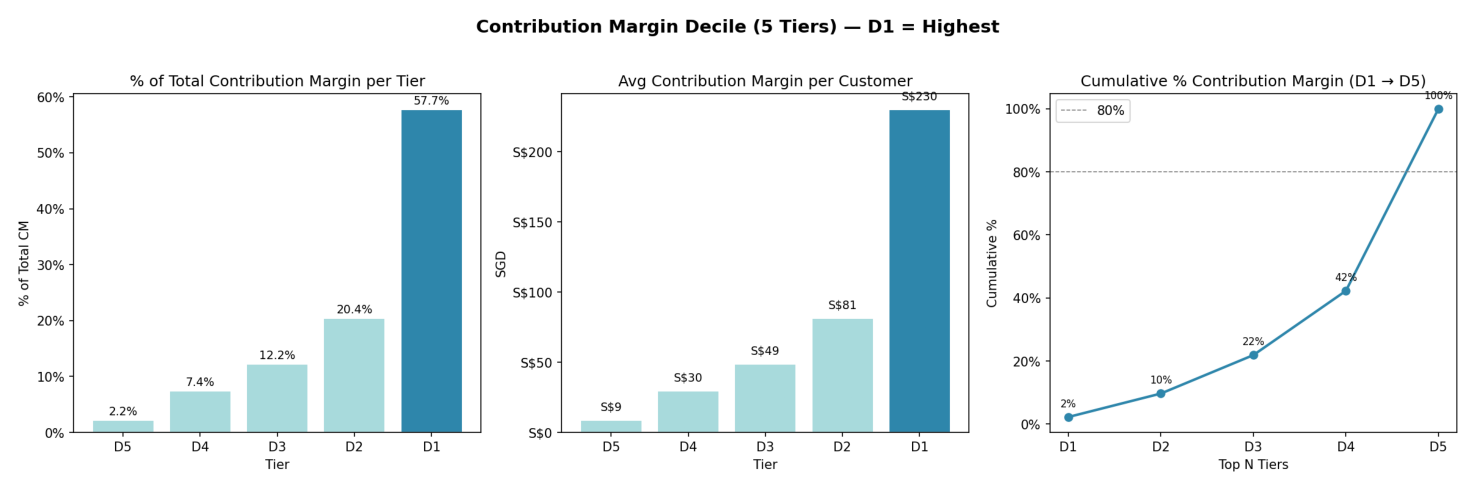


KEY RESULTS — Contribution Margin Decile
-------------------------------------------
Pool      : 4,290 customers | Each tier ~858 customers

D1 (top 20%) : generates roughly 58% of total contribution margin
D5 (bottom)  : generates roughly 2% of total contribution margin

What this means:
  Every tier has the same number of customers, but D1 customers are
  worth dramatically more per head than D5 customers. Contribution
  margin (not just revenue) is heavily concentrated at the top —
  this accounts for real product cost, so it's a more honest
  measure of who's actually profitable, not just who spends a lot.



In [2]:
img = mpimg.imread(FINALS_DIR / "decile_contribution_margin.png")
fig, ax = plt.subplots(figsize=(16, 5))
ax.imshow(img); ax.axis('off')
plt.tight_layout(); plt.show()

print("""
KEY RESULTS — Contribution Margin Decile
-------------------------------------------
Pool      : 4,290 customers | Each tier ~858 customers

D1 (top 20%) : generates roughly 58% of total contribution margin
D5 (bottom)  : generates roughly 2% of total contribution margin

What this means:
  Every tier has the same number of customers, but D1 customers are
  worth dramatically more per head than D5 customers. Contribution
  margin (not just revenue) is heavily concentrated at the top —
  this accounts for real product cost, so it's a more honest
  measure of who's actually profitable, not just who spends a lot.
""")

---
## Chart 2: Order Frequency (AOF) Decile (D1 = Most Frequent)

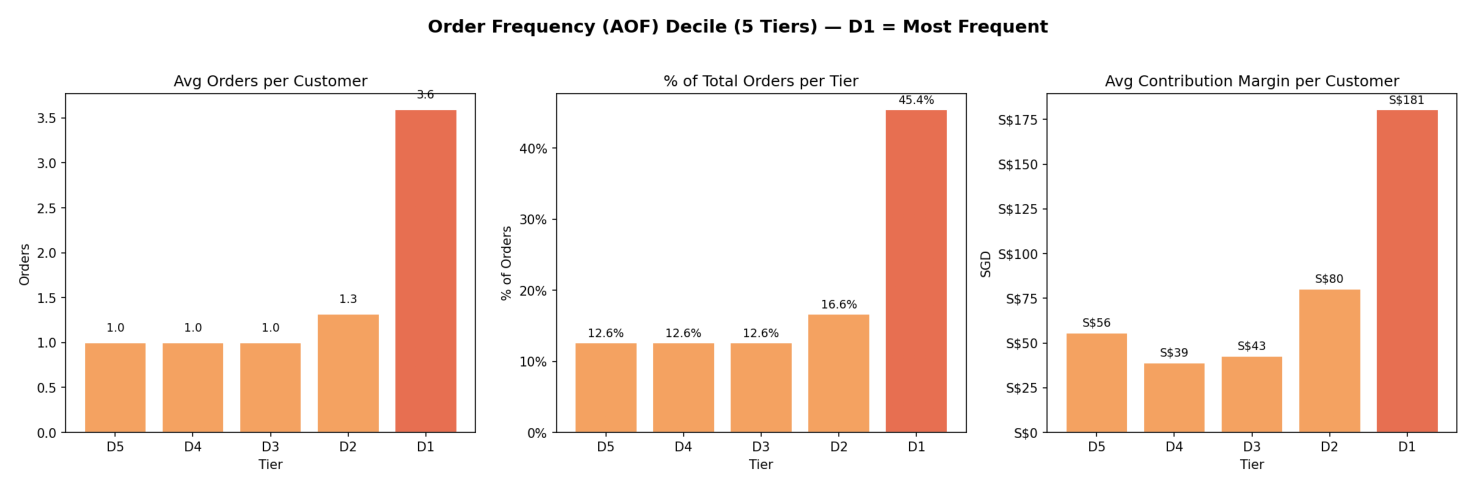


KEY RESULTS — Order Frequency (AOF) Decile
----------------------------------------------
Pool      : 4,290 customers | Each tier ~858 customers

D1 (most frequent) : highest avg order count per customer
D5 (least frequent): mostly one-time buyers

What this means:
  AOF doesn't mean "average order value" — it means how many separate
  orders a customer placed. D1 here are your most loyal, most frequently
  returning customers, independent of how much they spend per order.
  Compare this to the Contribution Margin decile — D1 in one doesn't
  always mean D1 in the other (see overlap heatmap below).



In [3]:
img = mpimg.imread(FINALS_DIR / "decile_order_frequency.png")
fig, ax = plt.subplots(figsize=(16, 5))
ax.imshow(img); ax.axis('off')
plt.tight_layout(); plt.show()

print("""
KEY RESULTS — Order Frequency (AOF) Decile
----------------------------------------------
Pool      : 4,290 customers | Each tier ~858 customers

D1 (most frequent) : highest avg order count per customer
D5 (least frequent): mostly one-time buyers

What this means:
  AOF doesn't mean "average order value" — it means how many separate
  orders a customer placed. D1 here are your most loyal, most frequently
  returning customers, independent of how much they spend per order.
  Compare this to the Contribution Margin decile — D1 in one doesn't
  always mean D1 in the other (see overlap heatmap below).
""")

---
## Chart 3: Overlap — Contribution Margin vs Order Frequency

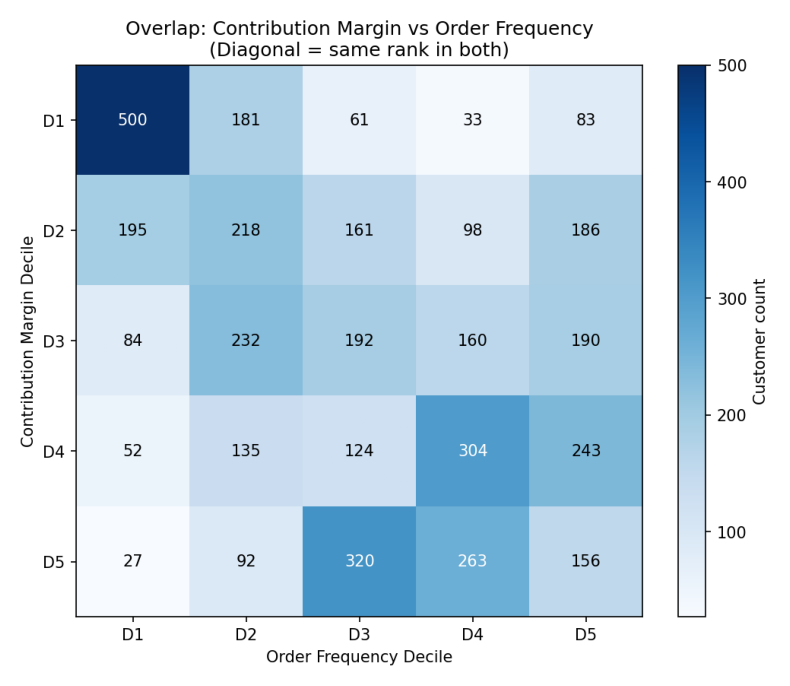


KEY RESULTS — Overlap: CM Decile vs AOF Decile
---------------------------------------------------
Each cell = number of customers who share that combination of
(Contribution Margin tier, Order Frequency tier).

What this means:
  If the diagonal is dark, customers who spend the most also order
  the most often — the two rankings broadly agree. If mass sits off
  the diagonal, the two metrics identify different customer groups —
  e.g. someone could be D1 in margin (high profit per order) but
  D3 in frequency (doesn't order that often).

  Customers who are D1 in BOTH are your highest-confidence VIPs —
  high profit AND high engagement. Use is_top_both == True in
  decile_customer_table.csv to pull this exact list.



In [4]:
img = mpimg.imread(FINALS_DIR / "decile_overlap_heatmap.png")
fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(img); ax.axis('off')
plt.tight_layout(); plt.show()

print("""
KEY RESULTS — Overlap: CM Decile vs AOF Decile
---------------------------------------------------
Each cell = number of customers who share that combination of
(Contribution Margin tier, Order Frequency tier).

What this means:
  If the diagonal is dark, customers who spend the most also order
  the most often — the two rankings broadly agree. If mass sits off
  the diagonal, the two metrics identify different customer groups —
  e.g. someone could be D1 in margin (high profit per order) but
  D3 in frequency (doesn't order that often).

  Customers who are D1 in BOTH are your highest-confidence VIPs —
  high profit AND high engagement. Use is_top_both == True in
  decile_customer_table.csv to pull this exact list.
""")

---
## How to Use `decile_customer_table.csv`

One row per customer (4,290 rows). Key columns:

| Column | Meaning |
|---|---|
| `customer_id` | Unique customer identifier |
| `finals_orders` | Number of orders placed (the AOF metric) |
| `finals_revenue` | Total net revenue |
| `true_gross_profit` | Contribution margin (Revenue − COGS) |
| `avg_margin_pct` | Average margin % across this customer's orders |
| `cogs_coverage_pct` | % of their revenue with real COGS data (vs 40% proxy fallback) |
| `contribution_margin_decile` | D1 (highest) to D5 (lowest), by contribution margin |
| `order_freq_decile` | D1 (most frequent) to D5 (least), by order count |
| `is_top_cm` | True if D1 in contribution margin |
| `is_top_freq` | True if D1 in order frequency |
| `is_top_both` | True if D1 in both — your highest-confidence VIP segment |


In [5]:
decile_table = pd.read_csv(FINALS_DIR / "decile_customer_table.csv")
print(f"Loaded decile_customer_table.csv — {len(decile_table):,} rows")
print()
print("Tier sizes — Contribution Margin:")
print(decile_table["contribution_margin_decile"].value_counts().sort_index().to_string())
print()
print("Tier sizes — Order Frequency:")
print(decile_table["order_freq_decile"].value_counts().sort_index().to_string())
print()
print(f"D1 in BOTH (is_top_both): {decile_table['is_top_both'].sum():,} customers")

Loaded decile_customer_table.csv — 4,290 rows

Tier sizes — Contribution Margin:
contribution_margin_decile
D1    858
D2    858
D3    858
D4    858
D5    858

Tier sizes — Order Frequency:
order_freq_decile
D1    858
D2    858
D3    858
D4    858
D5    858

D1 in BOTH (is_top_both): 500 customers


---
# Next Steps... hi Emily & Saelin, you guys can continue from here...

The decile tables and charts above are the foundation. The next step is to understand **who is actually
in each tier** — their behaviour, what they buy, which channel acquired them, whether they subscribe.

Below are starter cells for the **two D1 segments** (Contribution Margin D1, and Order Frequency D1) —
these are likely two overlapping but not identical groups. Run these first, then continue the same
pattern for D2, D3, D4, D5 by changing the filter.

**Suggested order of investigation:**
1. Profile D1 for both metrics (code below) — understand who your best customers actually are
2. Profile D2 for both metrics (code below, ready to run) — these are your "almost there" customers
3. Compare D1 vs D2 — what's different about their behaviour? Channel? Subscription? Product mix?
4. From there, the natural question becomes: **what would it take to move a D2 customer into D1?**
   Once you have the D2 output, paste it back and I'll help write the analysis on what's separating
   D2 from D1 and what could close that gap.


## D1 Behaviour — Contribution Margin

In [6]:
cust = pd.read_parquet(FINALS_DIR / "customers.parquet")
orders = pd.read_parquet(FINALS_DIR / "orders.parquet")

d1_cm_ids = decile_table[decile_table["contribution_margin_decile"] == "D1"]["customer_id"].astype(str)
d1_cm = cust[cust["customer_id"].astype(str).isin(d1_cm_ids)].copy()

print("=" * 60)
print(f"D1 — CONTRIBUTION MARGIN  ({len(d1_cm):,} customers)")
print("=" * 60)

print("\n[1] FINANCIALS")
print(f"  Avg contribution margin : S${d1_cm['true_gross_profit'].mean():,.2f}")
print(f"  Avg revenue              : S${d1_cm['finals_revenue'].mean():,.2f}")
print(f"  Avg margin %             : {d1_cm['avg_margin_pct'].mean():.1%}")
print(f"  Avg orders                : {d1_cm['finals_orders'].mean():.1f}")

print("\n[2] ACQUISITION CHANNEL")
print(d1_cm["first_channel"].value_counts(normalize=True).mul(100).round(1).to_string())

print("\n[3] SUBSCRIPTION BEHAVIOUR")
print(f"  Ever subscribed : {d1_cm['ever_subscribed'].mean():.1%}")

print("\n[4] PRODUCT BREADTH")
print(f"  Avg categories ever purchased : {d1_cm['n_categories_ever'].mean():.2f}")

print("\n[5] FIRST PRODUCT CATEGORY")
if "first_product_cat" in d1_cm.columns:
    print(d1_cm["first_product_cat"].value_counts(normalize=True).mul(100).round(1).to_string())

print("\n[6] ACQUISITION COHORT (year)")
print(d1_cm["acq_year"].value_counts().sort_index().to_string())

print("\n[7] DISCOUNT BEHAVIOUR ON FIRST ORDER")
print(f"  Avg first-order discount depth : {d1_cm['first_disc_depth'].mean():.1%}")
print(f"  Ever discounted (any order)    : {d1_cm['ever_discounted'].mean():.1%}")

D1 — CONTRIBUTION MARGIN  (858 customers)

[1] FINANCIALS
  Avg contribution margin : S$230.05
  Avg revenue              : S$374.69
  Avg margin %             : 69.1%
  Avg orders                : 3.1

[2] ACQUISITION CHANNEL
first_channel
Subscription        51.3
Direct / Organic    44.9
Paid Social          2.9
Email                0.6
Affiliate            0.3

[3] SUBSCRIPTION BEHAVIOUR
  Ever subscribed : 33.4%

[4] PRODUCT BREADTH
  Avg categories ever purchased : 2.26

[5] FIRST PRODUCT CATEGORY
first_product_cat
Unknown          25.5
Other            24.2
Clear Protein    21.7
Lean Protein     13.9
Collagen Glow     6.4
Accessories       6.3
Soy Protein       2.0

[6] ACQUISITION COHORT (year)
acq_year
2021      5
2022    207
2023     92
2024    248
2025    246
2026     60

[7] DISCOUNT BEHAVIOUR ON FIRST ORDER
  Avg first-order discount depth : 9.0%
  Ever discounted (any order)    : 75.5%


## D1 Behaviour — Order Frequency (AOF)

In [7]:
d1_freq_ids = decile_table[decile_table["order_freq_decile"] == "D1"]["customer_id"].astype(str)
d1_freq = cust[cust["customer_id"].astype(str).isin(d1_freq_ids)].copy()

print("=" * 60)
print(f"D1 — ORDER FREQUENCY (AOF)  ({len(d1_freq):,} customers)")
print("=" * 60)

print("\n[1] FINANCIALS")
print(f"  Avg orders                : {d1_freq['finals_orders'].mean():.1f}")
print(f"  Avg revenue                : S${d1_freq['finals_revenue'].mean():,.2f}")
print(f"  Avg contribution margin    : S${d1_freq['true_gross_profit'].mean():,.2f}")
print(f"  Avg margin %               : {d1_freq['avg_margin_pct'].mean():.1%}")

print("\n[2] ACQUISITION CHANNEL")
print(d1_freq["first_channel"].value_counts(normalize=True).mul(100).round(1).to_string())

print("\n[3] SUBSCRIPTION BEHAVIOUR")
print(f"  Ever subscribed : {d1_freq['ever_subscribed'].mean():.1%}")

print("\n[4] PRODUCT BREADTH")
print(f"  Avg categories ever purchased : {d1_freq['n_categories_ever'].mean():.2f}")

print("\n[5] FIRST PRODUCT CATEGORY")
if "first_product_cat" in d1_freq.columns:
    print(d1_freq["first_product_cat"].value_counts(normalize=True).mul(100).round(1).to_string())

print("\n[6] ACQUISITION COHORT (year)")
print(d1_freq["acq_year"].value_counts().sort_index().to_string())

print("\n[7] DISCOUNT BEHAVIOUR ON FIRST ORDER")
print(f"  Avg first-order discount depth : {d1_freq['first_disc_depth'].mean():.1%}")
print(f"  Ever discounted (any order)    : {d1_freq['ever_discounted'].mean():.1%}")

print("\n[8] OVERLAP CHECK")
overlap_with_cm_d1 = set(d1_freq["customer_id"].astype(str)) & set(d1_cm["customer_id"].astype(str))
print(f"  Also in Contribution Margin D1 : {len(overlap_with_cm_d1):,} / {len(d1_freq):,} "
      f"({len(overlap_with_cm_d1)/len(d1_freq):.1%})")

D1 — ORDER FREQUENCY (AOF)  (858 customers)

[1] FINANCIALS
  Avg orders                : 3.6
  Avg revenue                : S$297.30
  Avg contribution margin    : S$180.60
  Avg margin %               : 62.9%

[2] ACQUISITION CHANNEL
first_channel
Direct / Organic    52.3
Subscription        41.5
Paid Social          5.6
Affiliate            0.3
Email                0.2

[3] SUBSCRIPTION BEHAVIOUR
  Ever subscribed : 47.8%

[4] PRODUCT BREADTH
  Avg categories ever purchased : 2.22

[5] FIRST PRODUCT CATEGORY
first_product_cat
Unknown          29.1
Other            22.5
Clear Protein    16.0
Lean Protein     13.2
Accessories       8.7
Collagen Glow     8.2
Soy Protein       2.3

[6] ACQUISITION COHORT (year)
acq_year
2021      6
2022    196
2023    113
2024    231
2025    271
2026     41

[7] DISCOUNT BEHAVIOUR ON FIRST ORDER
  Avg first-order discount depth : 5.6%
  Ever discounted (any order)    : 64.7%

[8] OVERLAP CHECK
  Also in Contribution Margin D1 : 500 / 858 (58.3%)


## D2 Behaviour — Contribution Margin

Run this next. Once you have the output, paste it back and we'll write the analysis comparing
D2 to D1 — what's different, and what it might take to move D2 customers up a tier.

In [8]:
d2_cm_ids = decile_table[decile_table["contribution_margin_decile"] == "D2"]["customer_id"].astype(str)
d2_cm = cust[cust["customer_id"].astype(str).isin(d2_cm_ids)].copy()

print("=" * 60)
print(f"D2 — CONTRIBUTION MARGIN  ({len(d2_cm):,} customers)")
print("=" * 60)

print("\n[1] FINANCIALS")
print(f"  Avg contribution margin : S${d2_cm['true_gross_profit'].mean():,.2f}")
print(f"  Avg revenue              : S${d2_cm['finals_revenue'].mean():,.2f}")
print(f"  Avg margin %             : {d2_cm['avg_margin_pct'].mean():.1%}")
print(f"  Avg orders                : {d2_cm['finals_orders'].mean():.1f}")

print("\n[2] ACQUISITION CHANNEL")
print(d2_cm["first_channel"].value_counts(normalize=True).mul(100).round(1).to_string())

print("\n[3] SUBSCRIPTION BEHAVIOUR")
print(f"  Ever subscribed : {d2_cm['ever_subscribed'].mean():.1%}")

print("\n[4] PRODUCT BREADTH")
print(f"  Avg categories ever purchased : {d2_cm['n_categories_ever'].mean():.2f}")

print("\n[5] FIRST PRODUCT CATEGORY")
if "first_product_cat" in d2_cm.columns:
    print(d2_cm["first_product_cat"].value_counts(normalize=True).mul(100).round(1).to_string())

print("\n[6] ACQUISITION COHORT (year)")
print(d2_cm["acq_year"].value_counts().sort_index().to_string())

print("\n[7] DISCOUNT BEHAVIOUR ON FIRST ORDER")
print(f"  Avg first-order discount depth : {d2_cm['first_disc_depth'].mean():.1%}")
print(f"  Ever discounted (any order)    : {d2_cm['ever_discounted'].mean():.1%}")

print("\n[8] DIRECT COMPARISON TO D1")
print(f"  D1 avg CM : S${d1_cm['true_gross_profit'].mean():,.2f}  vs  D2 avg CM : S${d2_cm['true_gross_profit'].mean():,.2f}")
print(f"  D1 avg orders : {d1_cm['finals_orders'].mean():.1f}  vs  D2 avg orders : {d2_cm['finals_orders'].mean():.1f}")
print(f"  D1 subscribed : {d1_cm['ever_subscribed'].mean():.1%}  vs  D2 subscribed : {d2_cm['ever_subscribed'].mean():.1%}")
print(f"  D1 avg categories : {d1_cm['n_categories_ever'].mean():.2f}  vs  D2 avg categories : {d2_cm['n_categories_ever'].mean():.2f}")

D2 — CONTRIBUTION MARGIN  (858 customers)

[1] FINANCIALS
  Avg contribution margin : S$81.25
  Avg revenue              : S$122.04
  Avg margin %             : 70.5%
  Avg orders                : 1.5

[2] ACQUISITION CHANNEL
first_channel
Direct / Organic    51.2
Subscription        42.8
Paid Social          4.8
Affiliate            0.9
Email                0.3

[3] SUBSCRIPTION BEHAVIOUR
  Ever subscribed : 22.3%

[4] PRODUCT BREADTH
  Avg categories ever purchased : 1.68

[5] FIRST PRODUCT CATEGORY
first_product_cat
Clear Protein    33.0
Other            20.6
Lean Protein     18.2
Unknown          15.3
Accessories       6.2
Collagen Glow     5.4
Soy Protein       1.4

[6] ACQUISITION COHORT (year)
acq_year
2021      1
2022    105
2023     76
2024    271
2025    258
2026    147

[7] DISCOUNT BEHAVIOUR ON FIRST ORDER
  Avg first-order discount depth : 9.4%
  Ever discounted (any order)    : 67.8%

[8] DIRECT COMPARISON TO D1
  D1 avg CM : S$230.05  vs  D2 avg CM : S$81.25
  D1 avg ord

## D2 Behaviour — Order Frequency (AOF)

Same idea, for the frequency-based D2. Run this, paste the output back, and we'll cover what
separates a once-or-twice buyer from your most frequent repeat customers.

In [9]:
d2_freq_ids = decile_table[decile_table["order_freq_decile"] == "D2"]["customer_id"].astype(str)
d2_freq = cust[cust["customer_id"].astype(str).isin(d2_freq_ids)].copy()

print("=" * 60)
print(f"D2 — ORDER FREQUENCY (AOF)  ({len(d2_freq):,} customers)")
print("=" * 60)

print("\n[1] FINANCIALS")
print(f"  Avg orders                : {d2_freq['finals_orders'].mean():.1f}")
print(f"  Avg revenue                : S${d2_freq['finals_revenue'].mean():,.2f}")
print(f"  Avg contribution margin    : S${d2_freq['true_gross_profit'].mean():,.2f}")
print(f"  Avg margin %               : {d2_freq['avg_margin_pct'].mean():.1%}")

print("\n[2] ACQUISITION CHANNEL")
print(d2_freq["first_channel"].value_counts(normalize=True).mul(100).round(1).to_string())

print("\n[3] SUBSCRIPTION BEHAVIOUR")
print(f"  Ever subscribed : {d2_freq['ever_subscribed'].mean():.1%}")

print("\n[4] PRODUCT BREADTH")
print(f"  Avg categories ever purchased : {d2_freq['n_categories_ever'].mean():.2f}")

print("\n[5] FIRST PRODUCT CATEGORY")
if "first_product_cat" in d2_freq.columns:
    print(d2_freq["first_product_cat"].value_counts(normalize=True).mul(100).round(1).to_string())

print("\n[6] ACQUISITION COHORT (year)")
print(d2_freq["acq_year"].value_counts().sort_index().to_string())

print("\n[7] DISCOUNT BEHAVIOUR ON FIRST ORDER")
print(f"  Avg first-order discount depth : {d2_freq['first_disc_depth'].mean():.1%}")
print(f"  Ever discounted (any order)    : {d2_freq['ever_discounted'].mean():.1%}")

print("\n[8] DIRECT COMPARISON TO D1")
print(f"  D1 avg orders : {d1_freq['finals_orders'].mean():.1f}  vs  D2 avg orders : {d2_freq['finals_orders'].mean():.1f}")
print(f"  D1 avg CM : S${d1_freq['true_gross_profit'].mean():,.2f}  vs  D2 avg CM : S${d2_freq['true_gross_profit'].mean():,.2f}")
print(f"  D1 subscribed : {d1_freq['ever_subscribed'].mean():.1%}  vs  D2 subscribed : {d2_freq['ever_subscribed'].mean():.1%}")
print(f"  D1 avg categories : {d1_freq['n_categories_ever'].mean():.2f}  vs  D2 avg categories : {d2_freq['n_categories_ever'].mean():.2f}")

D2 — ORDER FREQUENCY (AOF)  (858 customers)

[1] FINANCIALS
  Avg orders                : 1.3
  Avg revenue                : S$125.77
  Avg contribution margin    : S$80.31
  Avg margin %               : 68.9%

[2] ACQUISITION CHANNEL
first_channel
Direct / Organic    57.7
Subscription        34.8
Paid Social          6.2
Affiliate            0.7
Email                0.5
Paid Search          0.1

[3] SUBSCRIPTION BEHAVIOUR
  Ever subscribed : 14.2%

[4] PRODUCT BREADTH
  Avg categories ever purchased : 1.51

[5] FIRST PRODUCT CATEGORY
first_product_cat
Clear Protein    28.2
Lean Protein     26.5
Unknown          17.7
Other            17.5
Accessories       5.2
Collagen Glow     2.7
Soy Protein       2.2

[6] ACQUISITION COHORT (year)
acq_year
2021      3
2022    149
2023     29
2024     85
2025    184
2026    408

[7] DISCOUNT BEHAVIOUR ON FIRST ORDER
  Avg first-order discount depth : 6.4%
  Ever discounted (any order)    : 51.7%

[8] DIRECT COMPARISON TO D1
  D1 avg orders : 3.6  vs 

## D1 vs D2 — What Separates Them, and What Could Close the Gap

### Contribution Margin: D1 vs D2

| Metric | D1 | D2 | Gap |
|---|---|---|---|
| Avg contribution margin | S$230.05 | S$81.25 | 2.8x |
| Avg orders | 3.1 | 1.5 | 2x |
| Ever subscribed | 33.4% | 22.3% | +11.1pp |
| Avg categories | 2.26 | 1.68 | +0.58 |
| Ever discounted | 75.5% | 67.8% | +7.7pp |

**The single biggest driver is order count, not margin rate.** D1 and D2 actually have
similar margin percentages (69.1% vs 70.5%) — D2 customers are just as profitable
*per dollar spent*. What separates them is that D1 customers order **2x more often**
and buy across **more categories** (2.26 vs 1.68). This means D2 is not a "discount problem"
or a "low-value product" problem — it's a **frequency and breadth problem**.

**Actionable signal:** subscription rate is 11pp higher in D1. Combined with the 2x order
gap, this points to subscription as a lever — non-subscribers who buy once may simply
not be coming back without a nudge. Cross-selling into a 2nd or 3rd category (Rec C from
the founder deck) is the other lever, since category breadth tracks closely with margin tier.

**Cohort note:** D2 contribution margin skews more recent (2024–2026 = 676 of 858, vs
D1's 554 of 858). This likely means many D2 customers simply haven't had time to place
a second order yet — not all of D2 is "stuck," some of it is "still new."

---

### Order Frequency: D1 vs D2

| Metric | D1 | D2 | Gap |
|---|---|---|---|
| Avg orders | 3.6 | 1.3 | 2.8x |
| Avg contribution margin | S$180.60 | S$80.31 | 2.2x |
| Ever subscribed | 47.8% | 14.2% | **+33.6pp** |
| Avg categories | 2.22 | 1.51 | +0.71 |
| Ever discounted | 64.7% | 51.7% | +13pp |

**Subscription is the standout differentiator here.** A 33.6 percentage point gap is far
larger than anything seen in the contribution margin comparison. Nearly half of D1-frequency
customers have subscribed at some point, versus only 1 in 7 in D2. This is the clearest
single signal in either comparison — **subscription strongly predicts repeat order frequency.**

**Cohort note — this is significant:** 408 of D2's 858 customers (47.6%) were acquired in
2026 alone. This is a much heavier recent skew than the contribution margin D2 (147 in 2026).
This means a large chunk of frequency-D2 is simply **too new to have ordered again yet** —
their "low frequency" may not reflect disengagement, just insufficient time elapsed.

---

### Combined Takeaway

Both D2 segments point to the same two levers:
1. **Subscription conversion** — the gap is large and consistent across both metrics,
   especially stark in the frequency comparison (33.6pp)
   2. **Category cross-sell** — D1 customers buy from more categories in both comparisons,
   suggesting basket breadth and repeat behaviour reinforce each other

But the recency skew (especially in frequency-D2, where 47.6% are 2026 acquisitions) means
**not all of D2 is equally actionable.** A useful next cut would be to split D2 into
"new and not yet repeated" vs "old and still hasn't repeated" — the second group is the
real retention risk, the first just needs time and a well-timed nudge.